
# Bearings-only tracking example

Non-linear bearing-only target tracking is a complex problem for estimating a
target's state from bearing measurements from a sensor.
From bearing-only measurements we can estimate the parameters of the target
motion (range and course). This is a non-linear problem caused by the non-linearity
between the measurements and the target state vector.

In this short tutorial we show how we can run a bearing-only simulation inside the Stone Soup framework.

In this tutorial, we simulate a radar placed on top of a moving platform collecting measurements,
then using the :class:`~.ExtendedKalmanFilter` we track the target. In this example we employ a
distance-based data associator to merge the hypothesis and the detections from the sensor.


## Layout
The layout of this example follows:

1) Create the moving platform and the :class:`~.RadarBearing` detector;
2) Generate the target ground truth paths;
3) Set up the simulation for generating detections from the ground truth paths;
4) Run the simulation and create the plots



In [89]:
# some general imports
import numpy as np
from matplotlib import pyplot as plt

from datetime import datetime
from datetime import timedelta

# Load Stone Soup materials
from stonesoup.types.state import State, GaussianState
from stonesoup.types.array import StateVector, CovarianceMatrix
from stonesoup.models.transition.linear import (CombinedLinearGaussianTransitionModel, ConstantVelocity)
from stonesoup.models.measurement.nonlinear import Cartesian2DToBearing

# Load the filter components
from stonesoup.updater.kalman import ExtendedKalmanUpdater
from stonesoup.predictor.kalman import ExtendedKalmanPredictor
from stonesoup.deleter.time import UpdateTimeStepsDeleter
from stonesoup.tracker.simple import SingleTargetTracker

# set a random seed and start of the simulation
np.random.seed(2001)
start_time = datetime.now()

datetime.datetime(2025, 12, 11, 13, 45, 13, 215897)

## 1) Create the moving platform and the Bearing-Only radar
Firstly, we create the initial state of the platform, including the origin point and the
cartesian (x, y) movement direction. Then, we create a transition model (in 2D cartesian coordinates)
of the platform.
At this point, we can set up the Radar which receives only the bearing measurements from the targets using the
:class:`~.RadarBearing` sensor.



In [90]:
# Import the platform to place the sensor
from stonesoup.platform.base import MovingPlatform

# Define the platform location, place it in the origin, and define its Cartesian movements.
# In addition, specify the position and velocity mapping. This is done in 2D Cartesian coordinates.

platform_state_vector = StateVector([[0], [-5], [0], [-7]])
position_mapping = (0, 2)
velocity_mapping = (1, 3)

# Create the initial state (position and time)
platform_state = State(platform_state_vector, start_time)

# Create a platform transition model, let's assume it is moving with constant velocity
platform_transition_model = CombinedLinearGaussianTransitionModel([
    ConstantVelocity(0.0), ConstantVelocity(0.0)])

# We can instantiate the platform's initial state, position and velocity mapping, and 
# the transition model using the  :class:`~.MovingPlatform` platform class.
platform = MovingPlatform(states=platform_state,
                          position_mapping=position_mapping,
                          velocity_mapping=velocity_mapping,
                          transition_model=platform_transition_model)

# At this stage, we need to create the sensor, let's import the RadarBearing. 
# This sensor only provides the bearing measurements from the target detections, 
# the range is not specified.
from stonesoup.sensor.radar.radar import RadarBearing

# Configure the radar noise, since we are using just a single dimension we need to specify only the
# noise associated with the bearing dimension, we assume a bearing accuracy of +/- 0.025 degrees for 
# each measurement
noise_covar = CovarianceMatrix(np.array(np.diag([np.deg2rad(0.025) ** 2])))

# This radar needs to be informed of the x and y mapping of the target space.
radar_mapping = (0, 2)

# Instantiate the radar
radar = RadarBearing(ndim_state=4,
                     position_mapping=radar_mapping,
                     noise_covar=noise_covar)

# As presented in the other examples we have to place the sensor on the platform.
platform.add_sensor(radar)
# At this point we can also check the offset rotation or the mounting of the radar in respect to the
# platform as shown in other tutorials.

## 2) Generate the ground truth target movements
We now build a ground truth simulator of a single target with a transition model
and a known initial state.



In [91]:
# Load the single target ground truth simulator
from stonesoup.simulator.simple import SingleTargetGroundTruthSimulator

# Instantiate the transition model
transition_model = CombinedLinearGaussianTransitionModel([
    ConstantVelocity(1.0), ConstantVelocity(1.0)])

# Define the initial target state
# We use a Gaussian state to specify the initial
# 2D Cartesian position and velocity, and the accuracy
# using a covariance matrix.
initial_target_state = GaussianState([50, 0, 50, 0],
                                     np.diag([1, 1, 1, 1]) ** 2,
                                     timestamp=start_time)

# Set up the ground truth simulation
groundtruth_simulation = SingleTargetGroundTruthSimulator(
    transition_model=transition_model,
    initial_state=initial_target_state,
    timestep=timedelta(seconds=1),
    number_steps=100
)

SingleTargetGroundTruthSimulator(
    transition_model=CombinedLinearGaussianTransitionModel(
                         model_list=[ConstantVelocity(
                                        noise_diff_coeff=1.0,
                                        seed=None),
                                     ConstantVelocity(
                                        noise_diff_coeff=1.0,
                                        seed=None)],
                         seed=None),
    initial_state=GaussianState(
                      state_vector=StateVector([[50],
                                                [ 0],
                                                [50],
                                                [ 0]]),
                      covar=CovarianceMatrix([[1, 0, 0, 0],
                                              [0, 1, 0, 0],
                                              [0, 0, 1, 0],
                                              [0, 0, 0, 1]]),
                      timestamp=2025-

## 3) Set up the detection simulation that generates the bearing measurements
After defining the measurement model and simulation, we will use these components to run our example.
The measurement model is the :class:`~.Cartesian2DToBearing`.



In [92]:
# Define the measurement model using a Cartesian to bearing
meas_model = Cartesian2DToBearing(
    ndim_state=4,
    mapping=(0, 2),
    noise_covar=noise_covar)

# Import the PlatformDetectionSimulator
from stonesoup.simulator.platform import PlatformDetectionSimulator

sim = PlatformDetectionSimulator(groundtruth=groundtruth_simulation,
                                 platforms=[platform])

PlatformDetectionSimulator(
    groundtruth=SingleTargetGroundTruthSimulator(
                    transition_model=CombinedLinearGaussianTransitionModel(
                                         model_list=[ConstantVelocity(
                                                        noise_diff_coeff=1.0,
                                                        seed=None),
                                                     ConstantVelocity(
                                                        noise_diff_coeff=1.0,
                                                        seed=None)],
                                         seed=None),
                    initial_state=GaussianState(
                                      state_vector=StateVector([[50],
                                                                [ 0],
                                                                [50],
                                                                [ 0]]),
                           

## 4) Set up the tracker
Instantiate the filter components
Create an Extended Kalman Predictor



In [93]:
predictor = ExtendedKalmanPredictor(transition_model)

# Create an Extended Kalman Updater
updater = ExtendedKalmanUpdater(measurement_model=None)

ExtendedKalmanUpdater(
    measurement_model=None,
    force_symmetric_covariance=False,
    use_joseph_cov=False)

Given the complexity of the bearing-only tracking, let's feed the
same initial state to both the ground truth measurements and tracker
as Stone Soup, currently, does not have a bearing only initiator.



In [94]:
# Instantiate the single point initiator
from stonesoup.initiator.simple import SinglePointInitiator
initiator = SinglePointInitiator(
    prior_state=initial_target_state,
    measurement_model=meas_model)

SinglePointInitiator(
    prior_state=GaussianState(
                    state_vector=StateVector([[50],
                                              [ 0],
                                              [50],
                                              [ 0]]),
                    covar=CovarianceMatrix([[1, 0, 0, 0],
                                            [0, 1, 0, 0],
                                            [0, 0, 1, 0],
                                            [0, 0, 0, 1]]),
                    timestamp=2025-12-11 13:45:13.215897),
    measurement_model=Cartesian2DToBearing(
                          ndim_state=4,
                          mapping=(0, 2),
                          noise_covar=[[1.90385887e-07]],
                          seed=None,
                          rotation_offset=StateVector([[0.],
                                                       [0.],
                                                       [0.]]),
                          translation_

Add the hypothesiser components. We use a distance based hypothesiser using a Mahalanobis
distance to do the data association between the detections and the tracks.
Since we consider a single target case a simple nearest neighbour will be enough for the data associator.



In [95]:
# Load the hypothesiser and data associator
from stonesoup.hypothesiser.distance import DistanceHypothesiser
from stonesoup.measures import Mahalanobis

hypothesiser = DistanceHypothesiser(predictor, updater,
                                    measure=Mahalanobis(),
                                    missed_distance=5)

from stonesoup.dataassociator.neighbour import NearestNeighbour

data_associator = NearestNeighbour(hypothesiser)

# Instantiate the time based deleter
deleter = UpdateTimeStepsDeleter(time_steps_since_update=3)

# Build the Kalman tracker
kalman_tracker = SingleTargetTracker(
    initiator=initiator,
    deleter=deleter,
    detector=sim,
    data_associator=data_associator,
    updater=updater
)

SingleTargetTracker(
    initiator=SinglePointInitiator(
                  prior_state=GaussianState(
                                  state_vector=StateVector([[50],
                                                            [ 0],
                                                            [50],
                                                            [ 0]]),
                                  covar=CovarianceMatrix([[1, 0, 0, 0],
                                                          [0, 1, 0, 0],
                                                          [0, 0, 1, 0],
                                                          [0, 0, 0, 1]]),
                                  timestamp=2025-12-11 13:45:13.215897),
                  measurement_model=Cartesian2DToBearing(
                                        ndim_state=4,
                                        mapping=(0, 2),
                                        noise_covar=[[1.90385887e-07]],
                             

## 5) Run the simulation and create the plots
We have everything for running the simulation, we have the tracker, the sensor
detections and platform movements.



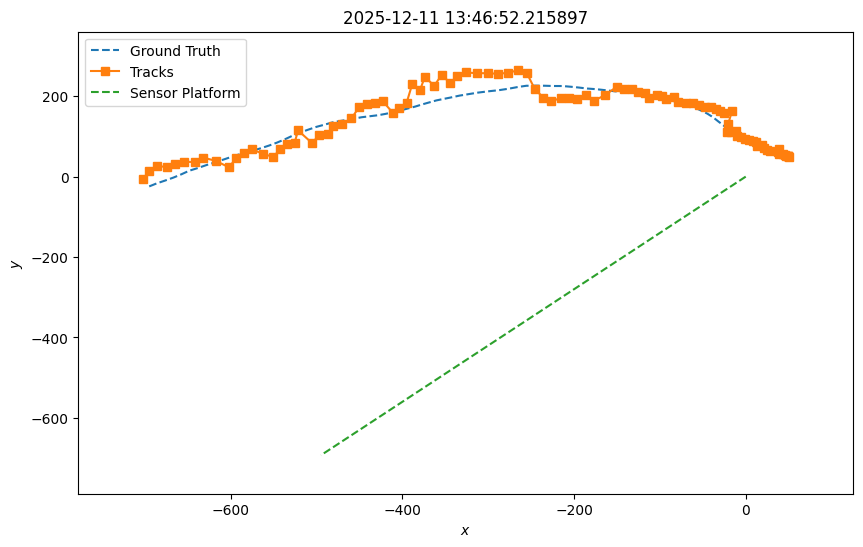

In [ ]:
kalman_tracks = {}  # Store for plotting later
groundtruth_paths = {}  # Store for plotting later

# Loop for the tracks and the ground truths
for time, ctracks in kalman_tracker:
    for track in ctracks:
        loc = (track.state_vector[0], track.state_vector[2])
        if track not in kalman_tracks:
            kalman_tracks[track] = []
        kalman_tracks[track].append(loc)

    for truth in groundtruth_simulation.current[1]:
        loc = (truth.state_vector[0], truth.state_vector[2])
        if truth not in groundtruth_paths:
            groundtruth_paths[truth] = []
        groundtruth_paths[truth].append(loc)

from stonesoup.plotter import AnimatedPlotterly, AnimationPlotter

plotter = AnimationPlotter(legend_kwargs=dict(loc='upper left'))
plotter.plot_ground_truths(groundtruth_paths, (0,2))
plotter.plot_tracks(kalman_tracks, (0,2))
plotter.plot_ground_truths(platform, (0,2), label="Sensor Platform")
anim = plotter.run()
from IPython.display import HTML
HTML(anim.to_jshtml())


This concludes this short tutorial on how to setup and run a simple single target
simulation using Bearings-Only measurements obtained by a moving sensor using an Extended Kalman Filter.



## References
[1] Xiangdong Lin, Thiagalingam Kirubarajan, Yaakov Bar-Shalom, Simon Maskell,
"Comparison of EKF, pseudomeasurement, and particle filters for a bearing-only target tracking problem", in
Signal and Data Processing of Small Targets 2002, 2002, vol 4728, pp. 240-250. doi:10.1117/12.478508
[2] Vincent J. Aidala, "Kalman Filter Behavior in Bearing-Only Tracking Applications", IEEE Transactions
on Aerospace Electronic Systems, Vol. 15, January 1979

